<a href="https://colab.research.google.com/github/tjdux/Introduction-to-Machine-Learning-with-Python/blob/main/03_3_%EB%8D%B0%EC%9D%B4%ED%84%B0_%EC%A0%84%EC%B2%98%EB%A6%AC%EC%99%80_%EC%8A%A4%EC%BC%80%EC%9D%BC_%EC%A1%B0%EC%A0%95.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# 노트북이 코랩에서 실행 중인지 체크합니다.
import os
import sys
if 'google.colab' in sys.modules and not os.path.isdir('mglearn'):
    # mglearn을 다운받고 압축을 풉니다.
    !wget -q -O mglearn.tar.gz https://bit.ly/mglearn-tar-gz
    !tar -xzf mglearn.tar.gz
    !wget -q -O data.tar.gz https://bit.ly/data-tar-gz
    !tar -xzf data.tar.gz
    # 나눔 폰트를 설치합니다.
    !sudo apt-get -qq -y install fonts-nanum
    import matplotlib.font_manager as fm
    font_files = fm.findSystemFonts(fontpaths=['/usr/share/fonts/truetype/nanum'])
    for fpath in font_files:
        fm.fontManager.addfont(fpath)

debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package fonts-nanum.
(Reading database ... 125080 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Processing triggers for fontconfig (2.13.1-4.2ubuntu5) ...


In [2]:
import sklearn
from preamble import *
import matplotlib

# 나눔 폰트를 사용합니다.
matplotlib.rc('font', family='NanumBarunGothic')
matplotlib.rcParams['axes.unicode_minus'] = False

/content/mglearn/datasets.py:31: SyntaxWarning: invalid escape sequence '\s'
  raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)


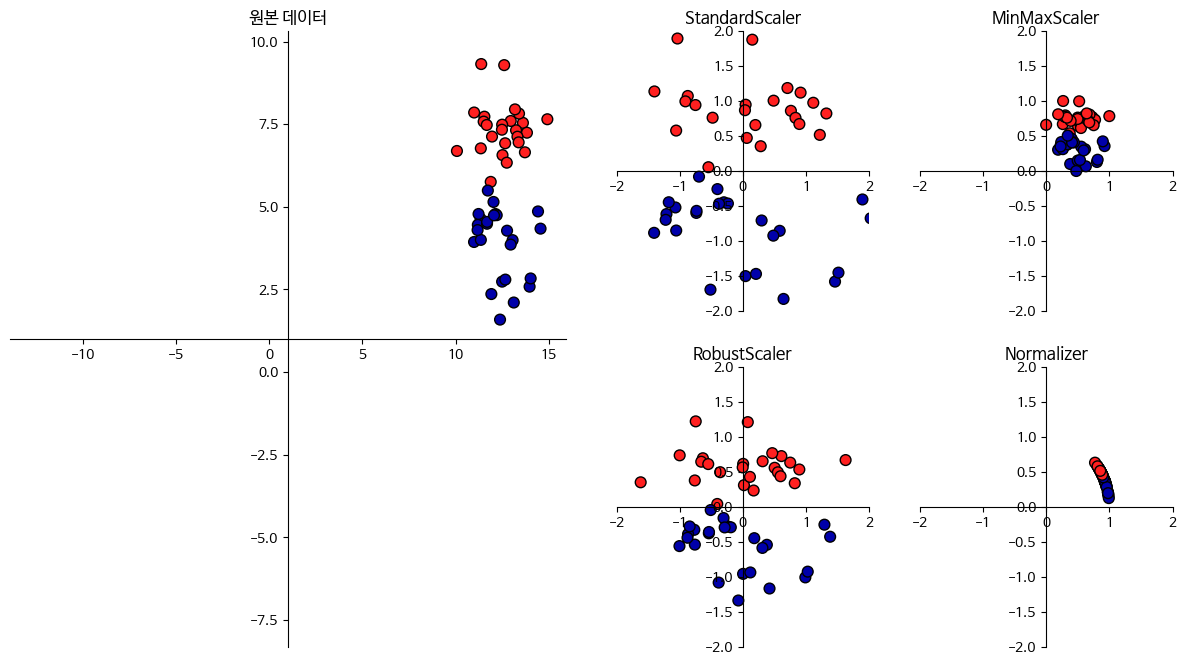

In [3]:
mglearn.plots.plot_scaling()

## 01 여러 가지 전처리 방법
- StandardScaler
  $$z = \frac{x - \bar x}{\sigma}
$$
  - 각 특성의 평균을 0, 분산을 1로 변경하여 모든 특성이 같은 크기를 가지게 함
  - 특성의 최솟값과 최댓값 크기를 제한하지는 않음
- RobustScaler
  $$z = \frac{x - q_2}{q_3 - q_1}
  $$
  - 특성들이 같은 스케일을 갖게 됨
  - 중간 값과 사분위 값을 사용
  - 이상치 (outlier)에 영향을 받지 않음
- MinMaxScaler
  $$z = \frac{x - x_{\min}}{x_{\max} - x_{\min}}
  $$
  - 모든 특성이 정확하게 0과 1 사이에 위치하도록 데이터를 변경
  - 2차원 데이터셋일 경우 모든 데이터가 x 축의 0과 1, y축의 0과 1 사이의 사각 영역에 담기게 됨
- Normalizer
  - 특성 벡터의 유클리디안 길이가 1이 되도록 데이터 포인트를 조정
  - 데이터 포인트가 다른 비율로 (길이에 반비례하여) 스케일이 조정
  - 특성 벡터의 길이는 상관 없고 데이터의 방향 (또는 각도)만이 중요할 때 많이 사용

## 02 데이터 변환 적용하기
- cancer 데이터셋에 커널 SVM을 적용하고 데이터 전처리에는 MinMaxScaler를 사용

In [4]:
# 데이터셋 나누기
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

cancer = load_breast_cancer()

X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target,
                                                    random_state=1)

print(X_train.shape)
print(X_test.shape)

(426, 30)
(143, 30)


In [8]:
# MinMaxScaler
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# 특성마다 최솟값과 최댓값을 계산
# X_train만 사용
scaler.fit(X_train)

# 데이터 변환
# transform(): 실제로 훈련 데이터의 스케일을 조정
X_train_scaled = scaler.transform(X_train)

# 스케일 조정 후 데이터셋의 속성
print(f"변환된 후 크기: {X_train_scaled.shape}")
print(f"스케일 조정 전 특성별 최솟값:\n {X_train.min(axis=0)}")
print(f"스케일 조정 전 특성별 최댓값:\n {X_train.max(axis=0)}")
print(f"스케일 조정 후 특성별 최솟값:\n {X_train_scaled.min(axis=0)}")
print(f"스케일 조정 후 특성별 최댓값:\n {X_train_scaled.max(axis=0)}")


변환된 후 크기: (426, 30)
스케일 조정 전 특성별 최솟값:
 [  6.981   9.71   43.79  143.5     0.053   0.019   0.      0.      0.106
   0.05    0.115   0.36    0.757   6.802   0.002   0.002   0.      0.
   0.01    0.001   7.93   12.02   50.41  185.2     0.071   0.027   0.
   0.      0.157   0.055]
스케일 조정 전 특성별 최댓값:
 [  28.11    39.28   188.5   2501.       0.163    0.287    0.427    0.201
    0.304    0.096    2.873    4.885   21.98   542.2      0.031    0.135
    0.396    0.053    0.061    0.03    36.04    49.54   251.2   4254.
    0.223    0.938    1.17     0.291    0.577    0.149]
스케일 조정 후 특성별 최솟값:
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0.]
스케일 조정 후 특성별 최댓값:
 [1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1.]


- 변환된 데이터의 배열 크기는 원래 데이터와 동일
- 특성 값이 이동되거나 크기가 조정

In [9]:
# 테스트 데이터 변환

# transform
# X_test 이용
X_test_scaled = scaler.transform(X_test)

print(f"스케일 조정 후 특성별 최솟값:\n {X_test_scaled.min(axis=0)}")
print(f"스케일 조정 후 특성별 최댓값:\n {X_test_scaled.max(axis=0)}")

스케일 조정 후 특성별 최솟값:
 [ 0.034  0.023  0.031  0.011  0.141  0.044  0.     0.     0.154 -0.006
 -0.001  0.006  0.004  0.001  0.039  0.011  0.     0.    -0.032  0.007
  0.027  0.058  0.02   0.009  0.109  0.026  0.     0.    -0.    -0.002]
스케일 조정 후 특성별 최댓값:
 [0.958 0.815 0.956 0.894 0.811 1.22  0.88  0.933 0.932 1.037 0.427 0.498
 0.441 0.284 0.487 0.739 0.767 0.629 1.337 0.391 0.896 0.793 0.849 0.745
 0.915 1.132 1.07  0.924 1.205 1.631]


- 일부 특성은 0 ~ 1 범위를 벗어남
- **모든 스케일 모델은 항상 훈련 세트와 테스트 세트에 같은 변환을 적용해야 함**
- **`transform()`은 테스트 세트의 최솟값과 범위를 사용하지 않고, 항상 훈련 세트의 최솟값을 빼고 훈련 세트의 범위로 나눔**


## 03 QuantileTransformer와 PowerTransformer

### 3.1 QuantileTransformer
- 기본적으로 1000개의 분위를 사용하여 데이터를 균등하게 분포
- 전체 데이터를 0과 1사이로 압축
- 이상치에 민감하지 않음

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_blobs
from sklearn.preprocessing import QuantileTransformer, StandardScaler, PowerTransformer

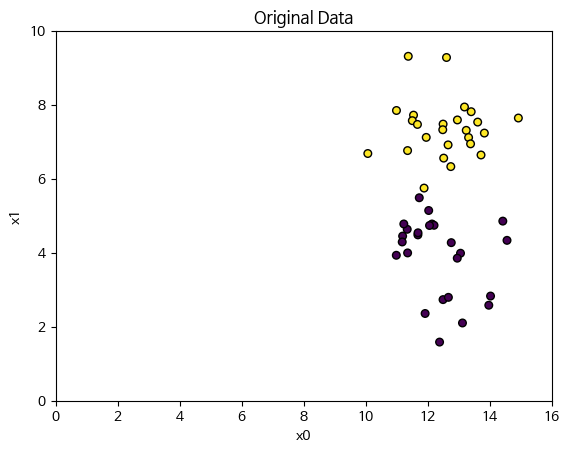

In [11]:
# 산점도

X, y = make_blobs(n_samples=50, centers=2, random_state=4, cluster_std=1)
X += 3

plt.scatter(X[:, 0], X[:, 1], c=y, s=30, edgecolors="black")
plt.xlim(0, 16)
plt.xlabel("x0")
plt.ylim(0, 10)
plt.ylabel("x1")
plt.title("Original Data")
plt.show()

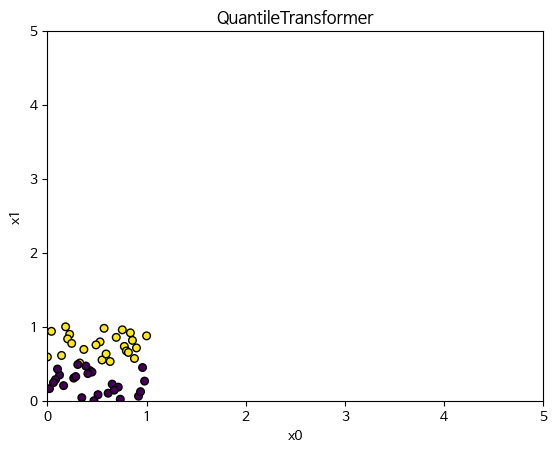

In [13]:
# QuantileTransformer를 적용해 스케일 변환

scaler = QuantileTransformer(n_quantiles=50)
X_trans = scaler.fit_transform(X)

plt.scatter(X_trans[:, 0], X_trans[:, 1], c=y, s=30, edgecolors="black")
plt.xlim(0, 5)
plt.xlabel("x0")
plt.ylim(0, 5)
plt.ylabel("x1")
plt.title(type(scaler).__name__)
plt.show()

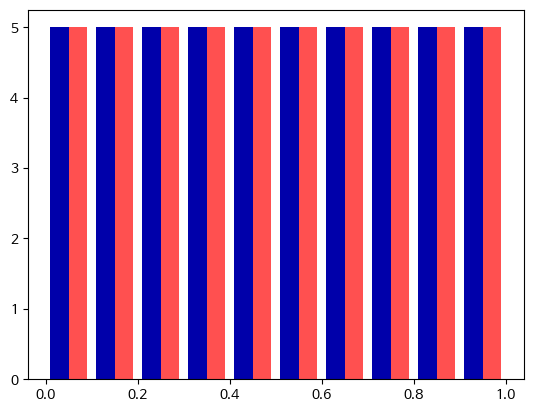

In [14]:
# 변환된 데이터의 히스토그램

plt.hist(X_trans)
plt.show()

In [15]:
# (n_quantiles, n_features)
print(scaler.quantiles_.shape)

(50, 2)


In [20]:
# 하나의 특성과 다섯 개의 샘플로 이루어진 데이터셋
# np.percentile(): 두 번째 매개변수에서 지정한 분위에 해당하는 샘플을 추출하여 반환

X = np.array([[0], [5], [8], [9], [10]])
print(f"변환 전: {np.percentile(X[:, 0], [0, 25, 50, 75, 100])}")

# QuantileTransformer로 변환
x_trans = QuantileTransformer(n_quantiles=5).fit_transform(X)
print(f"변환 후: {np.percentile(x_trans[:, 0], [0, 25, 50, 75, 100])}")

변환 전: [ 0.  5.  8.  9. 10.]
변환 후: [0.   0.25 0.5  0.75 1.  ]


- `output_distribution` 매개변수에 `normal`로 지정하여 균등 분포가 아닌 정규분포로 출력 변경 가능

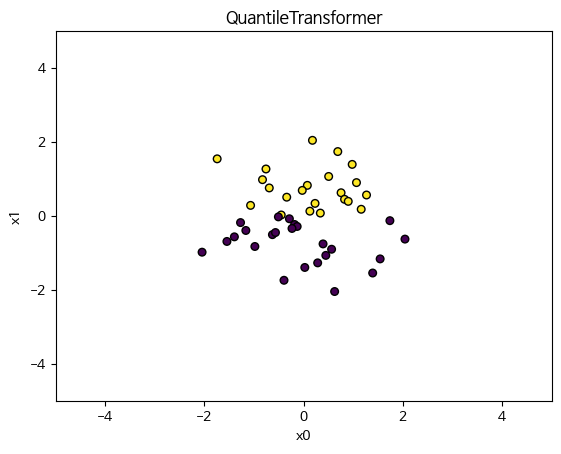

In [22]:
# 정규분포로 출력

X, y = make_blobs(n_samples=50, centers=2, random_state=4, cluster_std=1)
X += 3

scaler = QuantileTransformer(output_distribution="normal", n_quantiles=50)
X_trans = scaler.fit_transform(X)

plt.scatter(X_trans[:, 0], X_trans[:, 1], c=y, s=30, edgecolors="black")
plt.xlim(-5, 5)
plt.xlabel("x0")
plt.ylim(-5, 5)
plt.ylabel("x1")
plt.title(type(scaler).__name__)
plt.show()

### 3.2 PowerTransformer
- 데이터의 특성별로 정규분포 형태에 가깝도록 변환
- `method` 매개변수에 `yeo-johnson`와 `box-cox` 알고리즘 지정 가능

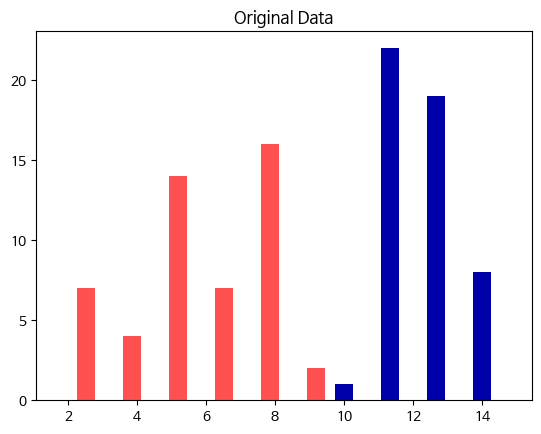

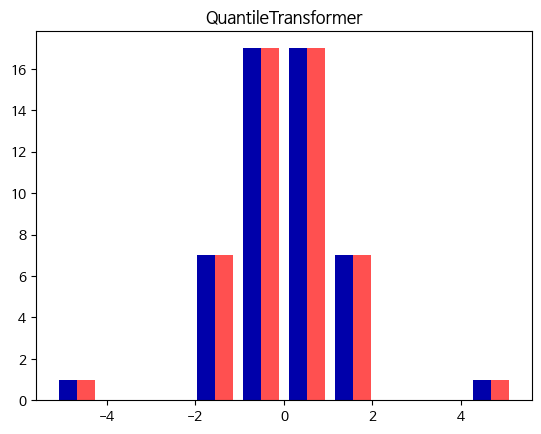

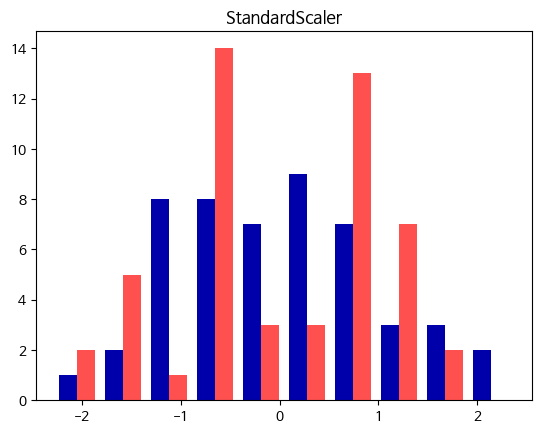

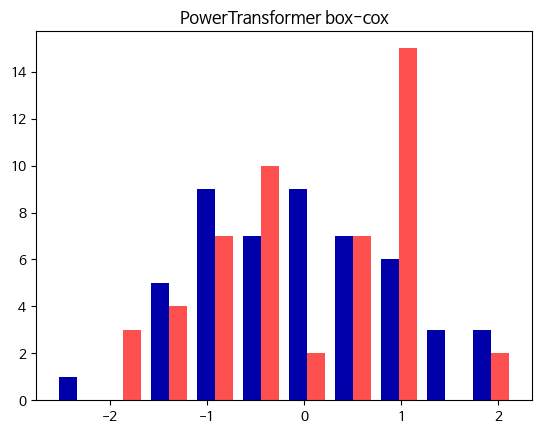

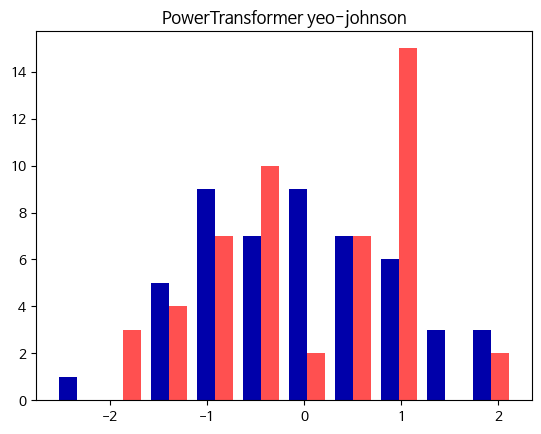

In [24]:
# QuantileTransformer, StandardScaler, PowerTransformer의 차이

plt.hist(X)
plt.title("Original Data")
plt.show()

X_trans = QuantileTransformer(output_distribution="normal", n_quantiles=50).fit_transform(X)
plt.hist(X_trans)
plt.title("QuantileTransformer")
plt.show()

X_trans = StandardScaler().fit_transform(X)
plt.hist(X_trans)
plt.title("StandardScaler")
plt.show()

X_trans = PowerTransformer(method='box-cox').fit_transform(X)
plt.hist(X_trans)
plt.title("PowerTransformer box-cox")
plt.show()

X_trans = PowerTransformer(method='yeo-johnson').fit_transform(X)
plt.hist(X_trans)
plt.title("PowerTransformer yeo-johnson")
plt.show()

## 04 훈련 데이터와 테스트 데이터의 스케일을 같은 방법으로 조정하기
- **✨ 훈련 세트와 테스트 세트에 같은 변환을 적용해야 함!**


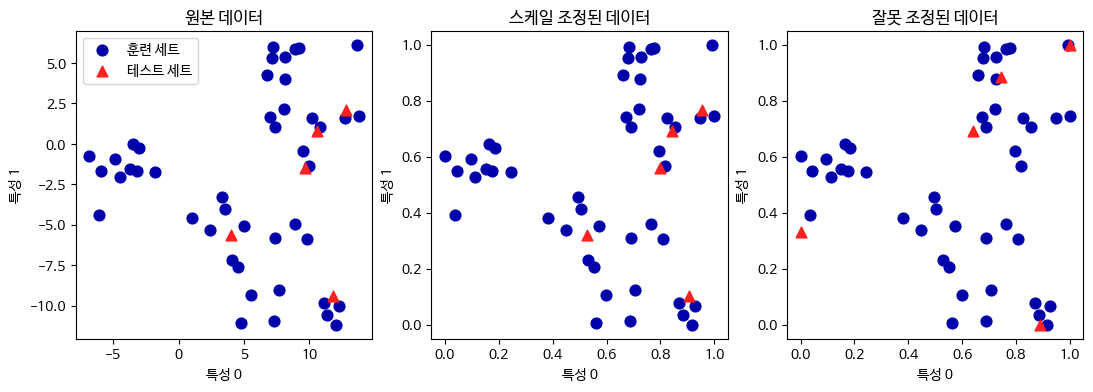

In [26]:
# 훈련 세트와 테스트 세트에 다른 변환을 적용했을 때 확인 🙄
from sklearn.datasets import make_blobs

X, _ = make_blobs(n_samples=50, centers=5, random_state=4, cluster_std=2)
X_train, X_test = train_test_split(X, random_state=5, test_size=.1)

# 1️⃣ 훈련 세트와 테스트 세트의 산점도
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].scatter(X_train[:, 0], X_train[:, 1],
                c=mglearn.cm2.colors[0], label="훈련 세트", s=60)
axes[0].scatter(X_test[:, 0], X_test[:, 1], marker="^",
                c=mglearn.cm2.colors[1], label="테스트 세트", s=60)
axes[0].legend(loc="upper left")
axes[0].set_title("원본 데이터")

# 2️⃣ MinMaxScaler를 사용하여 스케일 조정
scaler = MinMaxScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 스케일이 조정된 데이터의 산점도
axes[1].scatter(X_train_scaled[:, 0], X_train_scaled[:, 1],
                c=mglearn.cm2.colors[0], label="훈련 세트", s=60)
axes[1].scatter(X_test_scaled[:, 0], X_test_scaled[:, 1], marker="^",
                c=mglearn.cm2.colors[1], label="테스트 세트", s=60)
axes[1].set_title("스케일 조정된 데이터")

# 3️⃣ 테스트 세트의 스케일을 따로 조정
# 🙅‍♀️ 절대 사용 금지❗
test_scaler = MinMaxScaler()
test_scaler.fit(X_test)
X_test_scaled_badly = test_scaler.transform(X_test)

# 잘못 조정된 데이터의 산점도
axes[2].scatter(X_train_scaled[:, 0], X_train_scaled[:, 1],
                c=mglearn.cm2.colors[0], label="훈련 세트", s=60)
axes[2].scatter(X_test_scaled_badly[:, 0], X_test_scaled_badly[:, 1], marker="^",
                c=mglearn.cm2.colors[1], label="테스트 세트", s=60)
axes[2].set_title("잘못 조정된 데이터")

for ax in axes:
  ax.set_xlabel("특성 0")
  ax.set_ylabel("특성 1")

- 첫 번째 그래프, 두 번째 그래프
  - 축의 눈금이 바뀐 것만 제외하면 두 번째 그래프와 첫 번째 그래프는 동일
  - 모든 특성은 0과 1사이에 놓여 있지만, 테스트 데이터의 최솟값과 최댓값은 0과 1이 아님
- 세 번째 그래프
  - 훈련 세트와 테스트 세트의 최솟값과 최댓값이 모두 0과 1
  - 하지만 앞의 두 그래프와 다른 모양
  - 테스트 포인트가 훈련 세트와 다른 비율로 이동
  - 데이터 배열이 뒤죽박죽 됨

## 05 지도 학습에서 데이터 전처리 효과

In [27]:
# SVC 모델 이용
from sklearn.svm import SVC

X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target,
                                                    random_state=0)

svm = SVC(gamma="auto")
svm.fit(X_train, y_train)
print(f"테스트 세트 정확도: {round(svm.score(X_test, y_test), 2)}")

테스트 세트 정확도: 0.63


In [28]:
# MinMaxScaler로 데이터 스케일 조정

# 0~1 사이로 스케일 조정
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 조정된 데이터로 SVM 학습
svm.fit(X_train_scaled, y_train)

# 스케일 조정된 테스트 세트의 정확도
print(f"스케일 조정된 테스트 세트의 정확도: {round(svm.score(X_test_scaled, y_test), 2)}")

스케일 조정된 테스트 세트의 정확도: 0.95


In [29]:
# StandardScaler로 데이터 스케일 조정
from sklearn.preprocessing import StandardScaler

# 평균 0, 분산 1을 갖도록 스케일 조정
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 조정된 데이터로 SVM 학습
svm.fit(X_train_scaled, y_train)

# 스케일 조정된 테스트 세트의 정확도
print(f"스케일 조정된 테스트 세트의 정확도: {round(svm.score(X_test_scaled, y_test), 2)}")

스케일 조정된 테스트 세트의 정확도: 0.97
